# 01. Persistence and Climatology Baselines
This notebook builds and evaluates simple, non-learning baselines for predicting ground-level PM2.5 concentrations:
1. **Persistence Baseline**: Predictions are simply the target value from the previous day (`pm25_lag1`).
2. **Climatology Baseline**: Predictions are the station-specific monthly median PM2.5 computed from the train set split.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

ROOT = Path("../../")
DATA_PATH = ROOT / "data/processed/01_daily_merged.csv"

def split_df(df):
    TRAIN_FRAC = 0.70
    VAL_FRAC = 0.15
    dates = np.sort(df["date"].dt.normalize().unique())
    n = len(dates)
    tc = dates[int(n * TRAIN_FRAC)]
    vc = dates[int(n * (TRAIN_FRAC + VAL_FRAC))]
    df["split"] = "test"
    df.loc[df["date"] < tc, "split"] = "train"
    df.loc[(df["date"] >= tc) & (df["date"] < vc), "split"] = "val"
    return df

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = split_df(df)
print(df["split"].value_counts())


split
train    1283
test      741
val       542
Name: count, dtype: int64


## 1. Persistence Baseline
Evaluate model performance predicting today's PM2.5 as the previous day's PM2.5.

In [2]:
eval_df = df[df["pm25"].notna() & df["pm25_lag1"].notna()].copy()

results = {}
for split in ["train", "val", "test"]:
    split_df_sub = eval_df[eval_df["split"] == split]
    y_true = split_df_sub["pm25"].values
    y_pred = split_df_sub["pm25_lag1"].values
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results[split] = {"R2": r2, "MAE": mae, "RMSE": rmse}

print("=== Persistence Baseline ===")
for split, metrics in results.items():
    print(f"{split.capitalize()} -> R2: {metrics['R2']:.4f}, MAE: {metrics['MAE']:.3f}, RMSE: {metrics['RMSE']:.3f}")


=== Persistence Baseline ===
Train -> R2: 0.6537, MAE: 10.209, RMSE: 16.761
Val -> R2: 0.6375, MAE: 12.722, RMSE: 20.106
Test -> R2: 0.6191, MAE: 11.721, RMSE: 16.868


## 2. Climatology Baseline
Predicting using the station-specific monthly median calculated from the train set.

In [3]:
df["month"] = df["date"].dt.month
train_df = df[df["split"] == "train"]

climatology_map = train_df.groupby(["location_id", "month"])["pm25"].median().to_dict()
overall_train_median = train_df["pm25"].median()

def get_climatology_pred(row):
    return climatology_map.get((row["location_id"], row["month"]), overall_train_median)

df["pm25_clim_pred"] = df.apply(get_climatology_pred, axis=1)

results_clim = {}
for split in ["train", "val", "test"]:
    split_df_sub = df[df["split"] == split]
    y_true = split_df_sub["pm25"].values
    y_pred = split_df_sub["pm25_clim_pred"].values
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results_clim[split] = {"R2": r2, "MAE": mae, "RMSE": rmse}

print("=== Climatology Baseline ===")
for split, metrics in results_clim.items():
    print(f"{split.capitalize()} -> R2: {metrics['R2']:.4f}, MAE: {metrics['MAE']:.3f}, RMSE: {metrics['RMSE']:.3f}")


=== Climatology Baseline ===
Train -> R2: 0.4161, MAE: 13.965, RMSE: 21.746
Val -> R2: -0.2683, MAE: 25.476, RMSE: 37.572
Test -> R2: -0.3571, MAE: 22.186, RMSE: 31.838


## 3. Visualization
Plot predictions vs actual values on the test set split.

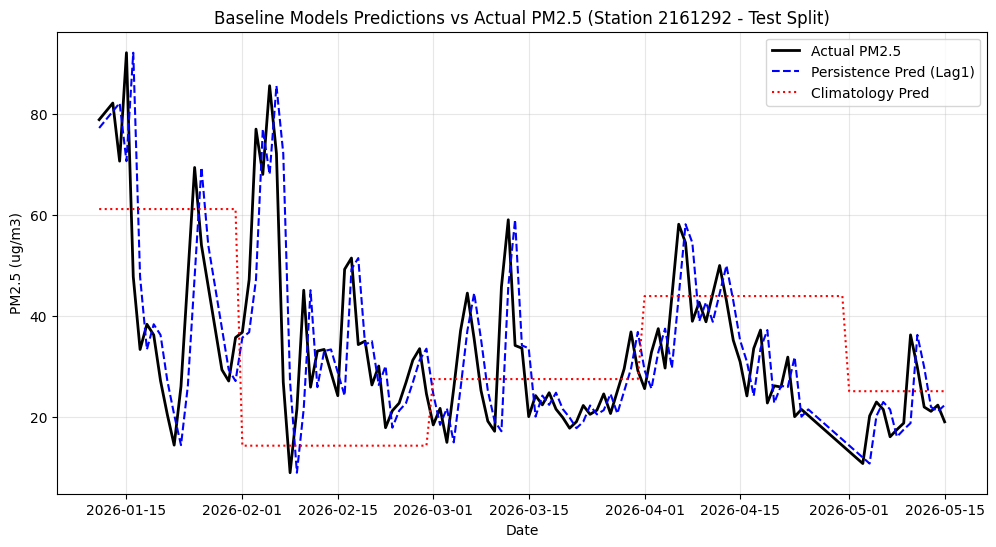

In [4]:
test_df = df[(df["split"] == "test") & (df["location_id"] == 2161292)].sort_values("date")
if len(test_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(test_df["date"], test_df["pm25"], label="Actual PM2.5", color="black", lw=2)
    plt.plot(test_df["date"], test_df["pm25_lag1"], label="Persistence Pred (Lag1)", color="blue", ls="--")
    plt.plot(test_df["date"], test_df["pm25_clim_pred"], label="Climatology Pred", color="red", ls=":")
    plt.title("Baseline Models Predictions vs Actual PM2.5 (Station 2161292 - Test Split)")
    plt.xlabel("Date")
    plt.ylabel("PM2.5 (ug/m3)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
